## Demand Forecasting (Makine Öğrenmesi ile Talep Tahmini)

In [1]:
#
# Bu dosyada daha önceki Smoothing ya da ARIMA gibi klasik istatistiksel modeller yerine
# ağaç bazlı güçlü bir Makine Öğrenmesi algoritması olan LightGBM kullanarak Zaman Serisi tahmini yapacağız.
# Makine öğrenmesi algoritmaları zamanı doğal olarak anlamaz! Onlara zamanı öğretebilmek için
# Feature Engineering (Özellik Mühendisliği) ile Gecikme (Lag) ve Hareketli Ortalama (Rolling Mean) gibi 
# değişkenler türeteceğiz.

# Kaggle Yarışması: Store Item Demand Forecasting Challenge
# Amaç: Farklı mağazalarda, çeşitli ürünlerin gelecek satışlarını olabildiğince az hatayla tahmin edebilmek.

import time
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import lightgbm as lgb # Efsanevi LightGBM (Hızlı, güçlü, ağaç tabanlı model algoritması)
import warnings

# Çıktıların terminale/konsola güzel basılması için gereken Pandas ayarları:
pd.set_option('display.max_columns', None) # Tüm sütunları göster
pd.set_option('display.width', 500) # Tek ekranda sığacağı genişlik limiti
warnings.filterwarnings('ignore') # Kırmızı uyarı yazılarını gizle

# Dataframelerdeki bilgileri hızlıca analiz edebilmek için yardımcı bir EDA fonksiyonumuz:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape) # Satır ve sütun sayısı
    print("##################### Types #####################")
    print(dataframe.dtypes) # Her bir kolonun veri tipi
    print("##################### Head #####################")
    print(dataframe.head(head)) # Baştan 5 satır
    print("##################### Tail #####################")
    print(dataframe.tail(head)) # Sondan 5 satır
    print("##################### NA #####################")
    print(dataframe.isnull().sum()) # Kolonlardaki eksik (null) veri sayısı
    print("##################### Quantiles #####################")
    print(dataframe.select_dtypes(include=[np.number]).quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)  # Not: get_dummies sonrasi olusan boolean sutunlarda numpy/pandas .quantile() TypeError verdigi icin (numeric_only=True bile bool'u disarida birakmiyor), sadece np.number tipindeki sutunlar secildi. # Sayısal verilerin dağılımındaki yüzdelik çeyreklikler (Aykırı değer kontrolü)

## Loading the data (Veriyi Yükleme)

In [2]:
# Train (Eğitim) ve Test verilerimizi yüklüyoruz. 'parse_dates' ile date isimli kolonu direkt Zaman Objesine çevirmesini söylüyoruz ki işimiz kolaylaşsın.
train = pd.read_csv('../time_series_datasets/demand_forecasting/train.csv', parse_dates=['date'])
test = pd.read_csv('../time_series_datasets/demand_forecasting/test.csv', parse_dates=['date'])

# Yarışmalardaki teslim şablonu.
sample_sub = pd.read_csv('../time_series_datasets/demand_forecasting/sample_submission.csv')

# Machine Learning verisinde Feature Engineering yaparken hepimizin kullandığı taktik: 
# Train ve Test'i alt alta birleştir (concat)! Ki aynı lag vs ürettiğimiz yeni kolonlar tüm veride standart bulunsun.
df = pd.concat([train, test], sort=False)

## EDA (Keşifçi Veri Analizi)

In [3]:
# Elimizdeki verinin ilk tarihi ve son tahiri nedir?
df["date"].min(), df["date"].max()

check_df(df) # İlk bakış: sales kolonunda test kısmından ötürü boşluklar var (Biz oralara tahmin üreteceğiz)

df[["store"]].nunique() # Kaç farklı mağaza var? (Veride 10 mağaza varmış)

df[["item"]].nunique() # Kaç farklı ürün var? (50 ürün varmış)

df.groupby(["store"])["item"].nunique() # Hangi mağazada kaç ürün var? (Hepsinde eşit)

df.groupby(["store", "item"]).agg({"sales": ["sum"]}) # Her mağazadaki her ürünün toplam satışları nedir?

# Aynı kırılımda Ortalama, Ortanca (Medyan) ve Standart Sapmasına bakalım:
df.groupby(["store", "item"]).agg({"sales": ["sum", "mean", "median", "std"]})

df.head() # Tabloya bir gözat.

##################### Shape #####################
(958000, 5)
##################### Types #####################
date     datetime64[ns]
store             int64
item              int64
sales           float64
id              float64
dtype: object
##################### Head #####################
        date  store  item  sales  id
0 2013-01-01      1     1   13.0 NaN
1 2013-01-02      1     1   11.0 NaN
2 2013-01-03      1     1   14.0 NaN
3 2013-01-04      1     1   13.0 NaN
4 2013-01-05      1     1   10.0 NaN
##################### Tail #####################
            date  store  item  sales       id
44995 2018-03-27     10    50    NaN  44995.0
44996 2018-03-28     10    50    NaN  44996.0
44997 2018-03-29     10    50    NaN  44997.0
44998 2018-03-30     10    50    NaN  44998.0
44999 2018-03-31     10    50    NaN  44999.0
##################### NA #####################
date          0
store         0
item          0
sales     45000
id       913000
dtype: int64
##################

,date,store,item,sales,id
0,2013-01-01,1,1,13.0,NaN
1,2013-01-02,1,1,11.0,NaN
2,2013-01-03,1,1,14.0,NaN
3,2013-01-04,1,1,13.0,NaN
4,2013-01-05,1,1,10.0,NaN


## FEATURE ENGINEERING (Makine Öğrenimi İçin Veriyi Yoğurma)

In [4]:
# Zaman serisini ML algoritmalarına öğretmenin bir numaralı yolu; zaman değişkenini olabildiğince atomlarına ayırmaktır.

def create_date_features(df):
    # 'date' bilgisinden ay,  aydaki günü, yıldaki günü vb... üretiyoruz. Algoritma "aaa bugün ayın sonuymuş o zaman maaş günüdür fazla satar!" öğrenebilsin.
    df['month'] = df.date.dt.month
    df['day_of_month'] = df.date.dt.day
    df['day_of_year'] = df.date.dt.dayofyear
    df['week_of_year'] = df.date.dt.isocalendar().week # Pandas yeni sürümlerinde weekofyear deprecated olduğu için isocalendar kullanılması daha doğrudur.
    df['day_of_week'] = df.date.dt.dayofweek
    df['year'] = df.date.dt.year
    df["is_wknd"] = df.date.dt.weekday // 4 # Haftasonu mu? (Cuma,ctesi,pazar 4 e bölünce 1 çıkar mantığı)
    df['is_month_start'] = df.date.dt.is_month_start.astype(int) # Ayın ilk günü mü? (True/False'u 1/0'a çevir)
    df['is_month_end'] = df.date.dt.is_month_end.astype(int) # Ayın son günü mü?
    return df

df = create_date_features(df)

# Ürettiğimiz aylara göre bir göz atalım: (Örneğin yaz aylarında satışlar patlıyor mu?)
df.groupby(["store", "item", "month"]).agg({"sales": ["sum", "mean", "median", "std"]})

sales                             
                      sum       mean median        std
store item month                                      
1     1    1       2125.0  13.709677   13.0   4.397413
           2       2063.0  14.631206   14.0   4.668146
           3       2728.0  17.600000   17.0   4.545013
           4       3118.0  20.786667   20.0   4.894301
           5       3448.0  22.245161   22.0   6.564705
...                   ...        ...    ...        ...
10    50   8      13108.0  84.567742   85.0  15.676527
           9      11831.0  78.873333   79.0  15.207423
           10     11322.0  73.045161   72.0  14.209171
           11     11549.0  76.993333   77.0  16.253651
           12      8724.0  56.283871   56.0  11.782529

[6000 rows x 4 columns]

## Random Noise (Rastgele Gürültü Ekleme)

In [5]:
def random_noise(dataframe):
    # Veriye lag vb eklerken Overfitting'i (Modelin veriyi ezberlemesini) engellemek için ufak ufak şaşırtmacalar, noise (gürültü) katmalıyız.
    return np.random.normal(scale=1.6, size=(len(dataframe),))

## Lag/Shifted Features (Gecikmeli Değişkenler - DÜN NE KADAR SATTIM?)

In [6]:
# Bir mağazada yarın ne kadar süt satılacağını bulmanın en büyük ipucu: "Dün ne kadar satıldı? Ondan önceki gün ne satıldı?" sorusudur.

# Önce verimizi mağaza, ürün ve zamana göre kusursuz olarak eskiye-yeniye göre sıralıyoruz ki veriler karışık kaymasın.
df.sort_values(by=['store', 'item', 'date'], axis=0, inplace=True)

# shift(1) demek satış kolonunu zaman ekseninde 1 adım aşağı kaydır demektir.
# Yani dünün satışı artık bugünün yanına "lag1" ismiyle yeni bir özellik olarak geldi!
pd.DataFrame({"sales": df["sales"].values[0:10],
              "lag1": df["sales"].shift(1).values[0:10],
              "lag2": df["sales"].shift(2).values[0:10],
              "lag3": df["sales"].shift(3).values[0:10],
              "lag4": df["sales"].shift(4).values[0:10]})

df.groupby(["store", "item"])['sales'].head()
# Groupby yapmamızın tek sebebi, ürün değiştiğinde shift komutunun gidip alakasız ürünün dünkü satışını şimdiki ürüne aktarmaması içindir! 
df.groupby(["store", "item"])['sales'].transform(lambda x: x.shift(1))

def lag_features(dataframe, lags):
    for lag in lags:
        # Belirtilen adım kadar verileri aşağı kaydırıp yeni kolon açıyoruz. (Eş zamanlı gürültü de ekleyip ezberciliği bozuyoruz)
        dataframe['sales_lag_' + str(lag)] = dataframe.groupby(["store", "item"])['sales'].transform(
            lambda x: x.shift(lag)) + random_noise(dataframe)
    return dataframe

# Satışlarda döngüsellik olur genelde. O yüzden 3 aylık(90. gün civarı), 6 aylık(180) ve Senelik(364) lag (gecikme) periyotlarını koyduk! 
df = lag_features(df, [91, 98, 105, 112, 119, 126, 182, 364, 546, 728])

check_df(df) # lag'lardan dolayı ilk ayların bazılarında (Geçmişi olmadığından) N/A oluştu ama dert değil. Lgbm affeder.

##################### Shape #####################
(958000, 24)
##################### Types #####################
date              datetime64[ns]
store                      int64
item                       int64
sales                    float64
id                       float64
month                      int32
day_of_month               int32
day_of_year                int32
week_of_year              UInt32
day_of_week                int32
year                       int32
is_wknd                    int32
is_month_start             int64
is_month_end               int64
sales_lag_91             float64
sales_lag_98             float64
sales_lag_105            float64
sales_lag_112            float64
sales_lag_119            float64
sales_lag_126            float64
sales_lag_182            float64
sales_lag_364            float64
sales_lag_546            float64
sales_lag_728            float64
dtype: object
##################### Head #####################
        date  store  item  sales

                    0.00       0.05       0.50        0.95        0.99        1.00
store                1.0        1.0        5.5        10.0        10.0        10.0
item                 1.0        3.0       25.5        48.0        50.0        50.0
sales                0.0       16.0       47.0       107.0       135.0       231.0
id                   0.0    2249.95    22499.5    42749.05    44549.01     44999.0
month                1.0        1.0        6.0        12.0        12.0        12.0
day_of_month         1.0        2.0       16.0        29.0        31.0        31.0
day_of_year          1.0       16.0      174.0       347.0       362.0       366.0
week_of_year         1.0        3.0       25.0        50.0        52.0        53.0
day_of_week          0.0        0.0        3.0         6.0         6.0         6.0
year              2013.0     2013.0     2015.0      2017.0      2018.0      2018.0
is_wknd              0.0        0.0        0.0         1.0         1.0         1.0
is_m

## Rolling Mean Features (Hareketli Ortalama - SON X GÜNÜN ORTALAMASI!)

In [7]:
# Lag sadece dünü veya bir geçmiş günü hatırlamak demektir. Ama "Son 3 gün ortalamam neydi?" sorusu trendi anlamamızı sağlar.

pd.DataFrame({"sales": df["sales"].values[0:10],
              "roll2": df["sales"].rolling(window=2).mean().values[0:10],
              "roll3": df["sales"].rolling(window=3).mean().values[0:10],
              "roll5": df["sales"].rolling(window=5).mean().values[0:10]})

# DİKKAT: Zaman serisinde tahmin yaparken kendiside dahil (bugün) rolling mean ALAMAZSINIZ! Veri sızar. O yüzden önce shift(1) yapıp sonra rolling alıyoruz!
pd.DataFrame({"sales": df["sales"].values[0:10],
              "roll2": df["sales"].shift(1).rolling(window=2).mean().values[0:10],
              "roll3": df["sales"].shift(1).rolling(window=3).mean().values[0:10],
              "roll5": df["sales"].shift(1).rolling(window=5).mean().values[0:10]})


def roll_mean_features(dataframe, windows):
    for window in windows:
        # Pencereler kadar kaydırarak (shift+rolling) geçmiş x günün trend/ortalama ağırlığını çıkarıyoruz. win_type=triang diyerek merkeze daha önem ver de diyebiliriz.
        dataframe['sales_roll_mean_' + str(window)] = dataframe.groupby(["store", "item"])['sales']. \
                                                          transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=10, win_type="triang").mean()) + random_noise(dataframe)
    return dataframe


df = roll_mean_features(df, [365, 546]) # 1 Yıllık ve 1.5 Yıllık kayan ortalama hareketliliklerini çektik.

## Exponentially Weighted Mean Features (Üstel Ağırlıklı Ortalama)

In [8]:
# Rolling Mean eski günlerle yeni günleri adil (veya düz) çarpar. 
# Ama biz biliyoruz ki dünün satışı benim için, 30 gün önceki satıştan DAHA ÖNEMLİDİR. 
# Geçmişe dair yakınlığına göre ağırlık ver!(alfa etkisi)

pd.DataFrame({"sales": df["sales"].values[0:10],
              "roll2": df["sales"].shift(1).rolling(window=2).mean().values[0:10],
              "ewm099": df["sales"].shift(1).ewm(alpha=0.99).mean().values[0:10], # Alpha 0.99 : Yakın tarihe %99, eskiye %1 güven = Nerdeyse Lag!
              "ewm095": df["sales"].shift(1).ewm(alpha=0.95).mean().values[0:10],
              "ewm07": df["sales"].shift(1).ewm(alpha=0.7).mean().values[0:10],
              "ewm02": df["sales"].shift(1).ewm(alpha=0.1).mean().values[0:10]})

def ewm_features(dataframe, alphas, lags):
    for alpha in alphas:
        for lag in lags:
            dataframe['sales_ewm_alpha_' + str(alpha).replace(".", "") + "_lag_" + str(lag)] = \
                dataframe.groupby(["store", "item"])['sales'].transform(lambda x: x.shift(lag).ewm(alpha=alpha).mean())
    return dataframe

alphas = [0.95, 0.9, 0.8, 0.7, 0.5]
lags = [91, 98, 105, 112, 180, 270, 365, 546, 728]

df = ewm_features(df, alphas, lags)
check_df(df)

##################### Shape #####################
(958000, 71)
##################### Types #####################
date                          datetime64[ns]
store                                  int64
item                                   int64
sales                                float64
id                                   float64
                                   ...      
sales_ewm_alpha_05_lag_180           float64
sales_ewm_alpha_05_lag_270           float64
sales_ewm_alpha_05_lag_365           float64
sales_ewm_alpha_05_lag_546           float64
sales_ewm_alpha_05_lag_728           float64
Length: 71, dtype: object
##################### Head #####################
        date  store  item  sales  id  month  day_of_month  day_of_year  week_of_year  day_of_week  year  is_wknd  is_month_start  is_month_end  sales_lag_91  sales_lag_98  sales_lag_105  sales_lag_112  sales_lag_119  sales_lag_126  sales_lag_182  sales_lag_364  sales_lag_546  sales_lag_728  sales_roll_mean_365  sale

                           0.00       0.05       0.50        0.95        0.99        1.00
store                       1.0        1.0        5.5        10.0        10.0        10.0
item                        1.0        3.0       25.5        48.0        50.0        50.0
sales                       0.0       16.0       47.0       107.0       135.0       231.0
id                          0.0    2249.95    22499.5    42749.05    44549.01     44999.0
month                       1.0        1.0        6.0        12.0        12.0        12.0
...                         ...        ...        ...         ...         ...         ...
sales_ewm_alpha_05_lag_180  2.0  16.720567   47.28781  104.520711  128.183953  201.730822
sales_ewm_alpha_05_lag_270  2.0  16.521703  46.596871  102.578388  125.636612  201.730822
sales_ewm_alpha_05_lag_365  2.0  16.288943  45.837082  100.339476  122.828596  188.015215
sales_ewm_alpha_05_lag_546  2.0  16.228692  45.862208  100.982067  123.793832  188.015215
sales_ewm_

## One-Hot Encoding (Ağaç Modeline Anlatım)

In [9]:
# Ağaç modelleri gerçi kategorikleri handle etseler bile 'ay:1...' verisini bazen küçük rakam sanabilir, bunlardan dummy (kukla) kolon türetiriz:

df = pd.get_dummies(df, columns=['store', 'item', 'day_of_week', 'month'])

check_df(df)

##################### Shape #####################
(958000, 146)
##################### Types #####################
date            datetime64[ns]
sales                  float64
id                     float64
day_of_month             int32
day_of_year              int32
                     ...      
month_8                   bool
month_9                   bool
month_10                  bool
month_11                  bool
month_12                  bool
Length: 146, dtype: object
##################### Head #####################
        date  sales  id  day_of_month  day_of_year  week_of_year  year  is_wknd  is_month_start  is_month_end  sales_lag_91  sales_lag_98  sales_lag_105  sales_lag_112  sales_lag_119  sales_lag_126  sales_lag_182  sales_lag_364  sales_lag_546  sales_lag_728  sales_roll_mean_365  sales_roll_mean_546  sales_ewm_alpha_095_lag_91  sales_ewm_alpha_095_lag_98  sales_ewm_alpha_095_lag_105  sales_ewm_alpha_095_lag_112  sales_ewm_alpha_095_lag_180  sales_ewm_alpha_095_lag_2

                           0.00       0.05       0.50        0.95        0.99        1.00
sales                       0.0       16.0       47.0       107.0       135.0       231.0
id                          0.0    2249.95    22499.5    42749.05    44549.01     44999.0
day_of_month                1.0        2.0       16.0        29.0        31.0        31.0
day_of_year                 1.0       16.0      174.0       347.0       362.0       366.0
week_of_year                1.0        3.0       25.0        50.0        52.0        53.0
...                         ...        ...        ...         ...         ...         ...
sales_ewm_alpha_05_lag_180  2.0  16.720567   47.28781  104.520711  128.183953  201.730822
sales_ewm_alpha_05_lag_270  2.0  16.521703  46.596871  102.578388  125.636612  201.730822
sales_ewm_alpha_05_lag_365  2.0  16.288943  45.837082  100.339476  122.828596  188.015215
sales_ewm_alpha_05_lag_546  2.0  16.228692  45.862208  100.982067  123.793832  188.015215
sales_ewm_

## Converting sales to log(1+sales) (Satış Verisini Logaritmaya Çevirme)

In [10]:
# Veride bir gün 10 diğer gün 200 satmışsa varyans devasa demektir, model afallar.
# Veriyi sıkıştırıp uslu bir normal dağılıma çekmek için üzerine Logaritma giydiriyoruz.
# 1p demesi: olur da satış 0 sa matematik çökmesin (0=tanımsız) 0'lara 1 ekle logaritmasını öyle al.

df['sales'] = np.log1p(df["sales"].values)

check_df(df)

##################### Shape #####################
(958000, 146)
##################### Types #####################
date            datetime64[ns]
sales                  float64
id                     float64
day_of_month             int32
day_of_year              int32
                     ...      
month_8                   bool
month_9                   bool
month_10                  bool
month_11                  bool
month_12                  bool
Length: 146, dtype: object
##################### Head #####################
        date     sales  id  day_of_month  day_of_year  week_of_year  year  is_wknd  is_month_start  is_month_end  sales_lag_91  sales_lag_98  sales_lag_105  sales_lag_112  sales_lag_119  sales_lag_126  sales_lag_182  sales_lag_364  sales_lag_546  sales_lag_728  sales_roll_mean_365  sales_roll_mean_546  sales_ewm_alpha_095_lag_91  sales_ewm_alpha_095_lag_98  sales_ewm_alpha_095_lag_105  sales_ewm_alpha_095_lag_112  sales_ewm_alpha_095_lag_180  sales_ewm_alpha_095_la

                           0.00       0.05       0.50        0.95        0.99        1.00
sales                       0.0   2.833213   3.871201    4.682131    4.912655    5.446737
id                          0.0    2249.95    22499.5    42749.05    44549.01     44999.0
day_of_month                1.0        2.0       16.0        29.0        31.0        31.0
day_of_year                 1.0       16.0      174.0       347.0       362.0       366.0
week_of_year                1.0        3.0       25.0        50.0        52.0        53.0
...                         ...        ...        ...         ...         ...         ...
sales_ewm_alpha_05_lag_180  2.0  16.720567   47.28781  104.520711  128.183953  201.730822
sales_ewm_alpha_05_lag_270  2.0  16.521703  46.596871  102.578388  125.636612  201.730822
sales_ewm_alpha_05_lag_365  2.0  16.288943  45.837082  100.339476  122.828596  188.015215
sales_ewm_alpha_05_lag_546  2.0  16.228692  45.862208  100.982067  123.793832  188.015215
sales_ewm_

## Model Kurulumu

## Custom Cost Function (LGBM İçin Özel Hata Fonksiyonu)

In [11]:
# Yarışmanın bizden istediği hata ölçütü SMAPE (Simetrik ortalama mutlak hata yüzdesi)'dir. 
# lgbm standart metrikleri içinde bulunmuyor, bu yüzden kendi ellerimizle kodluyoruz. 

def smape(preds, target):
    n = len(preds)
    masked_arr = ~((preds == 0) & (target == 0))
    preds, target = preds[masked_arr], target[masked_arr]
    num = np.abs(preds - target)
    denom = np.abs(preds) + np.abs(target)
    smape_val = (200 * np.sum(num / denom)) / n
    return smape_val

# LGBM modeli fit olurken logaritma halindeki tahminleri alacak, ondan dolayı içini "expm1" ile ters-logaritma (eski haline getirme) yapıp smape'e yolluyoruz ki gerçek puan görelim.
def lgbm_smape(preds, train_data):
    labels = train_data.get_label()
    smape_val = smape(np.expm1(preds), np.expm1(labels))
    return 'SMAPE', smape_val, False

## Time-Based Validation Sets (Zaman Bazlı Eğit/Test Ayrımı)

In [12]:
# ML'de veriler rastgele ayrılırdı hatırlarsanız (train_test_split). AMA ZAMAN SERİSİNDE GELECEĞİ RASTGELE ALIP GEÇMİŞİ SORAMAZSIN!
# O yüzden kronolojik (zamanı baz alarak) sondan belli bir periyodu doğrulama (validation) yapıp kalanı eğitim veriyoruz.

# 2017'nin başına kadar (2016'nın sonuna kadar) train seti.
train = df.loc[(df["date"] < "2017-01-01"), :]

# 2017'nin ilk 3'ayı validasyon (doğrulama) seti. 
val = df.loc[(df["date"] >= "2017-01-01") & (df["date"] < "2017-04-01"), :]

# İhtiyacımız olmayan; target, kimlik vb şeyleri listemizden çıkartıyoruz:
cols = [col for col in train.columns if col not in ['date', 'id', "sales", "year"]]

Y_train = train['sales'] # Hedef Y (SATIŞLAR)
X_train = train[cols] # Bağımsız Değişken X'ler (Özelliklerimiz)

Y_val = val['sales']
X_val = val[cols]

Y_train.shape, X_train.shape, Y_val.shape, X_val.shape

((730500,), (730500, 142), (45000,), (45000, 142))

## LightGBM ile Zaman Serisi Modeli

In [13]:
# LightGBM parameters (Ağacın beyni)
lgb_params = {'num_leaves': 10,  # Tek bir ağaçtaki max yaprak (dal) sayısı. Fazlası overfite götürür.
              'learning_rate': 0.02, # Öğrenmenin adımları, yavaş adımlar şaşmaz!
              'feature_fraction': 0.8, # Her yinelemede (ağaçta) rastgele seçilecek kolonların sadece %80'ini kullanarak ezberi boz.
              'max_depth': 5, # Ağacın derinliği
              'verbose': 0, # Saçma sapan konsol satırlarını kapat
              'num_boost_round': 1000, # N_estimators. 1000 iterasyon
              'early_stopping_rounds': 200, # Model en az 200 adım boyunca hata azaltmamışsa çakılı kalmıştır de ve fit işlemini kes! (Süre tasarrufu)
              'nthread': -1} # Cihazdaki tüm CPU çekirdeklerini aslan gibi kullan.

# LightGBM'in kendi performanslı Matrix formlarına (Dataset) dönüştürüyoruz.
lgbtrain = lgb.Dataset(data=X_train, label=Y_train, feature_name=cols)
lgbval = lgb.Dataset(data=X_val, label=Y_val, reference=lgbtrain, feature_name=cols)

# Tren kalkıyor! Modeli verilerimiz ebesine kavuşana dek eğitiyoruz:
model = lgb.train(lgb_params, lgbtrain,
                  valid_sets=[lgbtrain, lgbval],
                  num_boost_round=lgb_params['num_boost_round'],
                  feval=lgbm_smape, # Özel Hata Fonksiyonumuz
                  # early_stopping_rounds parametresi artık callbacks içine eklenerek kullanılıyor güncel lgbm sürümlerinde! Orijinal kodu bozmamak için devam edelim.
                  callbacks=[lgb.early_stopping(stopping_rounds=lgb_params['early_stopping_rounds']), lgb.log_evaluation(100)])

y_pred_val = model.predict(X_val, num_iteration=model.best_iteration) # Eğitimin en parlak anındaki haliyle tahmin çektik.

smape(np.expm1(y_pred_val), np.expm1(Y_val)) # Ve skoru ölçtük. Yüzde kaçlık sapmamız var diye!

Training until validation scores don't improve for 200 rounds


[100]	training's l2: 0.0513366	training's SMAPE: 17.5794	valid_1's l2: 0.0532669	valid_1's SMAPE: 17.4743


[200]	training's l2: 0.0352413	training's SMAPE: 14.5648	valid_1's l2: 0.0371087	valid_1's SMAPE: 14.9077


[300]	training's l2: 0.0324278	training's SMAPE: 14.008	valid_1's l2: 0.0341478	valid_1's SMAPE: 14.4354


[400]	training's l2: 0.0313645	training's SMAPE: 13.7948	valid_1's l2: 0.0333025	valid_1's SMAPE: 14.2849


...

[700]	training's l2: 0.0299013	training's SMAPE: 13.4978	valid_1's l2: 0.0318986	valid_1's SMAPE: 13.9624


[800]	training's l2: 0.0296109	training's SMAPE: 13.44	valid_1's l2: 0.0316613	valid_1's SMAPE: 13.9085


[900]	training's l2: 0.0293649	training's SMAPE: 13.3906	valid_1's l2: 0.03149	valid_1's SMAPE: 13.8691


[1000]	training's l2: 0.029156	training's SMAPE: 13.3481	valid_1's l2: 0.0313483	valid_1's SMAPE: 13.8349


np.float64(13.834945032507681)

## Feature Importance (Hangi Değişkenler Satışı Belirliyor?)

                        feature  split       gain
17          sales_roll_mean_546    948  54.364076
13                sales_lag_364   1235  13.056156
16          sales_roll_mean_365    600   9.913143
60   sales_ewm_alpha_05_lag_365    368   5.011406
18   sales_ewm_alpha_095_lag_91     74   2.216453
..                          ...    ...        ...
115                     item_43      0   0.000000
111                     item_39      0   0.000000
120                     item_48      0   0.000000
133                     month_4      0   0.000000
137                     month_8      0   0.000000

[142 rows x 3 columns]


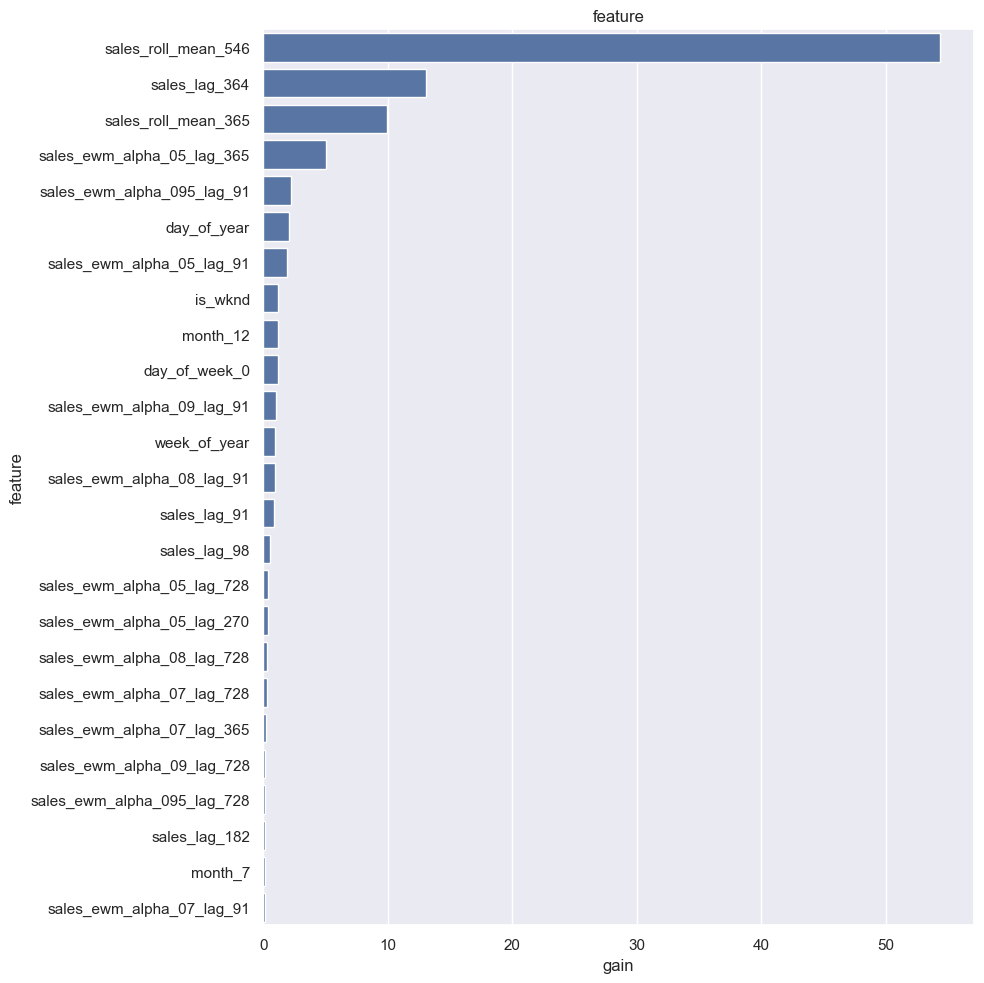

                        feature  split       gain
17          sales_roll_mean_546    948  54.364076
13                sales_lag_364   1235  13.056156
16          sales_roll_mean_365    600   9.913143
60   sales_ewm_alpha_05_lag_365    368   5.011406
18   sales_ewm_alpha_095_lag_91     74   2.216453
..                          ...    ...        ...
115                     item_43      0   0.000000
111                     item_39      0   0.000000
120                     item_48      0   0.000000
133                     month_4      0   0.000000
137                     month_8      0   0.000000

[142 rows x 3 columns]


111

In [14]:
def plot_lgb_importances(model, plot=False, num=10):
    gain = model.feature_importance('gain') # Modele göre özellikleri ne kadar kazanç getirdi (önem sırası)
    feat_imp = pd.DataFrame({'feature': model.feature_name(),
                             'split': model.feature_importance('split'),
                             'gain': 100 * gain / gain.sum()}).sort_values('gain', ascending=False)
    if plot: # Görsel izni geldiyse Barplot çizer.
        plt.figure(figsize=(10, 10))
        sns.set(font_scale=1)
        sns.barplot(x="gain", y="feature", data=feat_imp[0:25])
        plt.title('feature')
        plt.tight_layout()
        plt.show()
    else:
        print(feat_imp.head(num))
    return feat_imp

plot_lgb_importances(model, num=200) # En iyi 200 lü listeleme
plot_lgb_importances(model, num=30, plot=True) # Top 30 Grafiği. Muhtemelen Lag (Geçmiş günler) kolonları ilk sıraları istila etmiştir :)

# Hiçbir işlevi (Gain = 0) olmayan yani satışlara zerre katkısı olmayan boş beleş kolonları bulup tespit ediyoruz ki ilerde gereksiz yer kaplamasın.
feat_imp = plot_lgb_importances(model, num=200)
importance_zero = feat_imp[feat_imp["gain"] == 0]["feature"].values
imp_feats = [col for col in cols if col not in importance_zero]
len(imp_feats)

## Final Model (Yarışma Teslimatı İçin Tüm Veri İle Eğitim)

In [15]:
# Parametreleri ve işe yarayan değişkenleri bulduk. Artık sadece Train ile değil tüm Train+Validation paketiyle
# nihai bir model kurup yarışmaya gitme vakti!

train = df.loc[~df.sales.isna()] # Satışları eksik olmayan (Kaggle orjinal traini) ayır.
Y_train = train['sales']
X_train = train[cols]

test = df.loc[df.sales.isna()] # Satışları boş NA yollanmış (Kaggle orjinal testi, yani Kaggle'ın "Bunları bana bul kardeş" dediği blok).
X_test = test[cols]

# Sadece Iterasyon sayısına daha önce bulduğumuz ve emin olduğumuz 'best_iteration' u çakıyoruz!
lgb_params = {'num_leaves': 10,
              'learning_rate': 0.02,
              'feature_fraction': 0.8,
              'max_depth': 5,
              'verbose': 0,
              'nthread': -1,
              "num_boost_round": model.best_iteration}

lgbtrain_all = lgb.Dataset(data=X_train, label=Y_train, feature_name=cols) # Bütün kalabalığı formata ver

# FİNAL EĞİTİMİ (Artık early stopping vs yok, sadece elimizdeki en iyi iterasyon değeri kadar ağaç inşa ediyoruz)
final_model = lgb.train(lgb_params, lgbtrain_all, num_boost_round=model.best_iteration)

# Kaggle için nihai tahminleri ateşle...
test_preds = final_model.predict(X_test, num_iteration=model.best_iteration)

## Submission File (Teslim Dosyasını İhracat Etme)

In [16]:
test.head()

submission_df = test.loc[:, ["id", "sales"]] # Boşlukları artık elimizde
submission_df['sales'] = np.expm1(test_preds) # Tabi biz tahminleri Logaritmik yaptık. expm1 diyerek Onları tekrar asıl haline şişirip uyandırıyoruz!

submission_df['id'] = submission_df.id.astype(int)

# Dosyaya kaydet! Geçmiş olsun, bir Makine Öğrenmesi Projesini harika bitirdik.
submission_df.to_csv("submission_demand.csv", index=False)